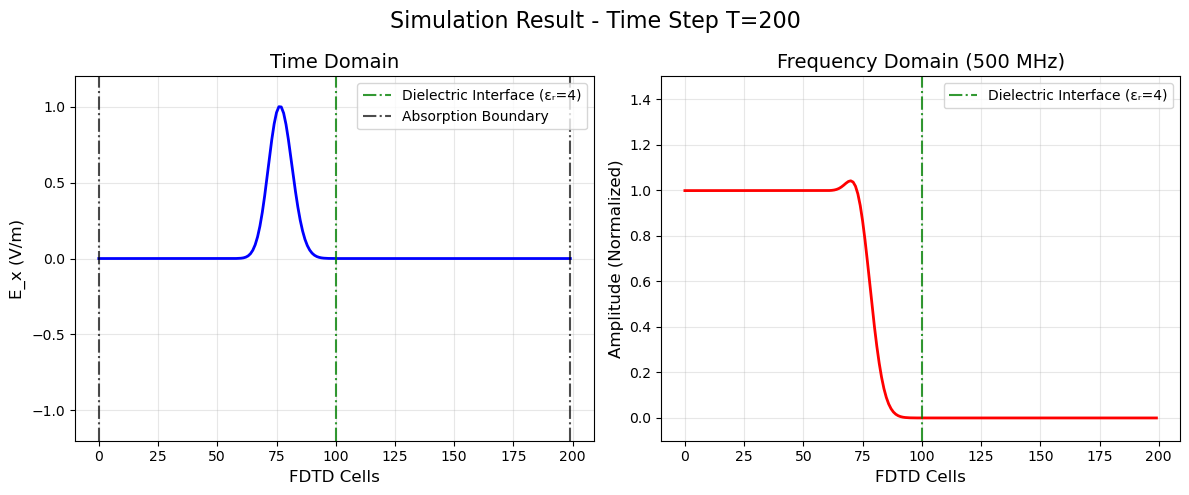

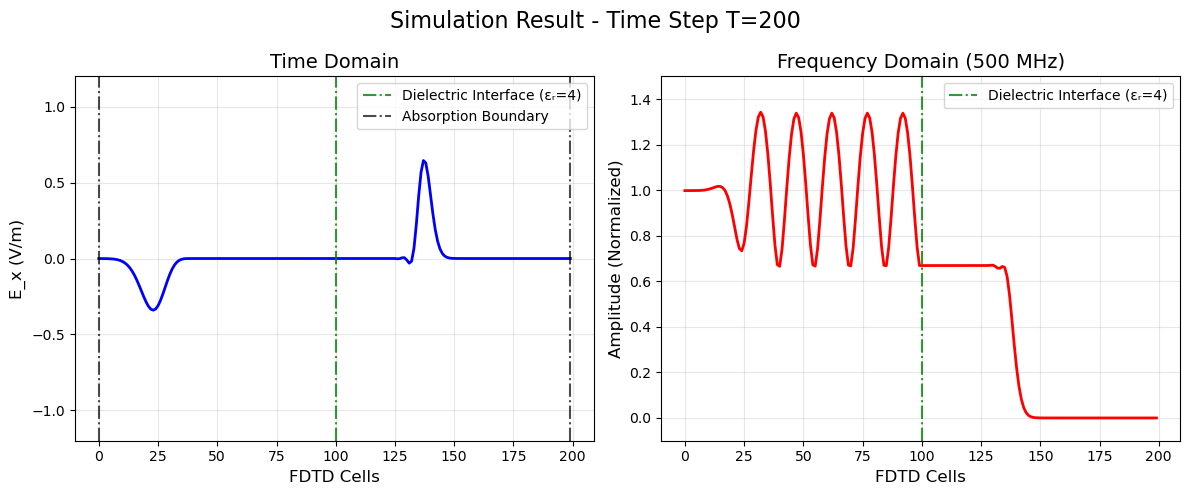

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ===================== 1. 物理常数与模拟参数（与原一致，确保基础正确） =====================
eps0 = 8.854e-12  # 真空介电常数 (F/m)
mu0 = 4 * np.pi * 1e-7  # 真空磁导率 (H/m)
c0 = 1 / np.sqrt(eps0 * mu0)  # 光速 (m/s)
nx = 200        # 空间网格数（D和E的网格数，H比E少1个）
nt = 400       # 时间步数


# 介质分区：左自由空间，右损耗介质（与原一致）
epsr_free = 1       # 自由空间相对介电常数
sigma_free = 0      # 自由空间电导率
epsr_lossy = 4      # 损耗介质相对介电常数
sigma_lossy = 0  # 损耗介质电导率
kstart_lossy = int(nx/2)  # 损耗介质起始网格（E和D的网格索引一致）

dt = 0.01 / 6e8  # 时间步长（dx=0.01m，满足Courant条件 dt <= dx/c0）
dx = 0.01  # 空间步长 (m)

# ===================== 2. 计算介质系数（严格匹配式2.10a/2.10b） =====================
gax_free = 1 / (epsr_free + (sigma_free * dt / eps0))
gbx_free = (sigma_free * dt) / eps0
# 2.2 损耗介质系数
gax_lossy = 1 / (epsr_lossy + (sigma_lossy * dt / eps0))
gbx_lossy = (sigma_lossy * dt) / eps0

# 初始化系数数组（分区域赋值，E、D、I共享同一套系数，正确）
gax = np.ones(nx) * gax_free
gbx = np.ones(nx) * gbx_free
gax[kstart_lossy:] = gax_lossy  # 损耗区赋值gax
gbx[kstart_lossy:] = gbx_lossy  # 损耗区赋值gbx

# ===================== 3. 数组初始化（区分物理量，保存历史值） =====================
# 核心物理量（严格对应推导定义）
dx = np.zeros(nx)   # dx[k]：电通量密度D的离散量（n时刻）
ex = np.zeros(nx)   # ex[k]：电场强度E的离散量（n时刻）
hy = np.zeros(nx) # hy[k]：磁场强度H的离散量（n-0.5 / n+0.5时刻，Yee交错）
ix = np.zeros(nx)   # ix[k]：损耗辅助量I的离散量（n时刻，累积项）

# 保存上一时刻的ix（I_prev = I^{n-1}，用于计算E^n = gax*(D^n - I^{n-1})）
ix_prev = np.zeros(nx)  # 关键：单独存储I的历史值，避免数据污染

# Mur一阶吸收边界（针对E，与原一致，但需同步D的边界）
prev_prev_ex1 = 0.0    # E[1]的n-2时刻值
prev_ex1 = 0.0         # E[1]的n-1时刻值
prev_prev_ex_nx2 = 0.0 # E[nx-2]的n-2时刻值
prev_ex_nx2 = 0.0      # E[nx-2]的n-1时刻值

prev_6_ex_nx2 = 0
prev_5_ex_nx2 = 0
prev_4_ex_nx2 = 0
prev_3_ex_nx2 = 0
prev_2_ex_nx2 = 0
prev_1_ex_nx2 = 0

# 高斯脉冲源参数（文档设定：近似冲激，含宽频谱）
src_pos = 2  # 源位置（网格索引）
t0 = 50.0     # 脉冲中心时间步
spread = 10.0 # 脉冲宽度（窄脉冲，覆盖500MHz频率）

# 实时DFT参数（目标频率：图2.1重点展示500MHz，额外添加100/200MHz）
freq_list = [100e6, 200e6, 1000e6]  # 目标频率（单位：Hz）
num_freq = len(freq_list)
arg = 2 * np.pi * np.array(freq_list) * dt  # 每个频率的相位步长（式2.14a/b核心）

# 实时DFT存储数组（式2.14a/b：实部+虚部）
real_pt = np.zeros((num_freq, nx))  # 每个频率、每个网格的DFT实部
imag_pt = np.zeros((num_freq, nx))  # 每个频率、每个网格的DFT虚部
real_in = np.zeros(num_freq)        # 入射脉冲的DFT实部（用于归一化）
imag_in = np.zeros(num_freq)        # 入射脉冲的DFT虚部（用于归一化）



# ===================== 4. FDTD时间循环（严格按推导顺序：D→E→I→H） =====================
for n in range(nt):

    t = n * dt  # 当前物理时间（n时刻，对应E和D的时刻）

    # ---------- 步骤1：更新电通量密度 ----------
    for k in range(nx):
        dx[k] += 0.5 * (hy[k-1] - hy[k])  # hy是n-0.5时刻的磁场

    # ---------- 步骤2：添加高斯脉冲源 ----------
    pulse = np.exp(-0.5 * ((t0 - n) / spread)**2)  # 高斯脉冲
    dx[src_pos] += pulse

    # ---------- 步骤3：计算电场强度E和辅助变量i----------
    for k in range(nx-1):
        ex[k] = gax[k] * (dx[k] - ix[k])
        ix[k] += gbx[k] * ex[k]

#------采用下面的更新方式可以消除边界的异常值-----------
    # # ---------- 步骤3：更新电场E（式2.9b：E = gax*(D - I)） ----------
    # ex_new = np.zeros(nx)
    # for k in range(nx):
    #     if k == 0:
    #         # 左边界Mur条件：E[0]^n = E[1]^{n-2}
    #         ex_new[k] = prev_prev_ex1
    #     elif k == nx-1:
    #         # 右边界Mur条件：E[nx-1]^n = E[nx-2]^{n-2}
    #         ex_new[k] = prev_prev_ex_nx2
    #     else:
    #         ex_new[k] = gax[k] * (dx[k] - ix[k])  # 无耗介质I=0，简化为E = gax*D
    
    # ex = ex_new  # 更新E场

    # # ---------- 步骤4：更新损耗辅助量I（式2.9c：I = I + gbx*E，无耗时gbx=0，I不变） ----------
    # ix += gbx * ex

    # ---------- 步骤5：实时计算DFT（式2.14a/b，同步累加实部和虚部） ----------
    for m in range(num_freq):
        # 累加每个网格的DFT分量
        real_pt[m, :] += ex * np.cos(arg[m] * (n+1))  # 式2.14a
        imag_pt[m, :] -= ex * np.sin(arg[m] * (n+1))  # 式2.14b
        
        # 累加入射脉冲的DFT（源位置附近网格，T<100时脉冲未传播）
        if n < 100:
            real_in[m] += ex[src_pos+10] * np.cos(arg[m] * (n+1))
            imag_in[m] -= ex[src_pos+10] * np.sin(arg[m] * (n+1))


    # ---------- 步骤4：更新Mur边界的E历史值----------
    #  it takes two time steps for the field to cross one cell in free space
    # 损耗介质中，一个Δt传播：约0.2491Δx
    ex[0]= prev_prev_ex1
    prev_prev_ex1 = prev_ex1
    prev_ex1 = ex[1]
    
    ex[nx-1]= prev_6_ex_nx2
    prev_6_ex_nx2 = prev_5_ex_nx2    
    prev_5_ex_nx2 = prev_4_ex_nx2
    prev_4_ex_nx2 = prev_3_ex_nx2
    prev_3_ex_nx2 = prev_2_ex_nx2
    prev_2_ex_nx2 = prev_1_ex_nx2
    prev_1_ex_nx2 = ex[nx-2]

    # ---------- 步骤5：更新磁场强度 ----------
    for k in range(nx-1):
        hy[k] += 0.5 * (ex[k] - ex[k+1])  # 用当前E^n更新H^{n+0.5}

    # ---------- 步骤8：存储关键时间步的E场（图2.1需要T=200和T=400） ----------
    if n == 199:  # T=200（第200个时间步，索引199）
        ex_t200 = ex.copy()

        # ===================== 5. 计算频域振幅（式2.15a，归一化后匹配图2.1） =====================
        amp = np.zeros((num_freq, nx))  # 每个频率的归一化振幅
        for m in range(num_freq):
            # 入射脉冲的振幅（用于归一化）
            amp_in = np.sqrt(real_in[m]**2 + imag_in[m]**2)
            # 每个网格的频域振幅（式2.15a）
            amp[m, :] = (np.sqrt(real_pt[m, :]**2 + imag_pt[m, :]**2)) / amp_in

        # 提取图2.1重点展示的500MHz振幅（索引2）
        amp_500mhz = amp[2, :]
        
        #绘图
        fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
        fig1.suptitle('Simulation Result - Time Step T=200', fontsize=16)

        # 子图1：T=200时域E场（脉冲未入射介质）
        ax1_1 = axes1[0]
        ax1_1.plot(ex_t200, color='blue', linewidth=2)
        ax1_1.axvline(kstart_lossy, color='green', linestyle='-.', alpha=0.8, label='Dielectric Interface (εᵣ=4)')
        ax1_1.axvline(0, color='black', linestyle='-.', alpha=0.7, label='Absorption Boundary')
        ax1_1.axvline(nx-1, color='black', linestyle='-.', alpha=0.7)
        ax1_1.set_xlabel('FDTD Cells', fontsize=12)
        ax1_1.set_ylabel('E_x (V/m)', fontsize=12)
        ax1_1.set_title('Time Domain', fontsize=14)
        ax1_1.set_ylim(-1.2, 1.2)
        ax1_1.legend(fontsize=10)
        ax1_1.grid(True, alpha=0.3)
        
        # 子图1.2：T=200 500MHz频域振幅
        ax1_2 = axes1[1]
        ax1_2.plot(amp_500mhz, color='red', linewidth=2)
        ax1_2.axvline(kstart_lossy, color='green', linestyle='-.', alpha=0.8, label='Dielectric Interface (εᵣ=4)')
        ax1_2.set_xlabel('FDTD Cells', fontsize=12)
        ax1_2.set_ylabel('Amplitude (Normalized)', fontsize=12)
        ax1_2.set_title('Frequency Domain (500 MHz)', fontsize=14)
        ax1_2.set_ylim(-0.1, 1.5)
        ax1_2.legend(fontsize=10)
        ax1_2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if n == 399:   
        ex_t400 = ex.copy()

        amp = np.zeros((num_freq, nx))  
        for m in range(num_freq):
            # 入射脉冲的振幅（用于归一化）
            amp_in = np.sqrt(real_in[m]**2 + imag_in[m]**2)
            # 每个网格的频域振幅（式2.15a）
            amp[m, :] = (np.sqrt(real_pt[m, :]**2 + imag_pt[m, :]**2)) / amp_in

        # 提取图2.1重点展示的500MHz振幅（索引2）
        amp_500mhz = amp[2, :]
        
        #绘图
        fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
        fig1.suptitle('Simulation Result - Time Step T=200', fontsize=16)

        # 子图1：T=200时域E场（脉冲未入射介质）
        ax1_1 = axes1[0]
        ax1_1.plot(ex_t400, color='blue', linewidth=2)
        ax1_1.axvline(kstart_lossy, color='green', linestyle='-.', alpha=0.8, label='Dielectric Interface (εᵣ=4)')
        ax1_1.axvline(0, color='black', linestyle='-.', alpha=0.7, label='Absorption Boundary')
        ax1_1.axvline(nx-1, color='black', linestyle='-.', alpha=0.7)
        ax1_1.set_xlabel('FDTD Cells', fontsize=12)
        ax1_1.set_ylabel('E_x (V/m)', fontsize=12)
        ax1_1.set_title('Time Domain', fontsize=14)
        ax1_1.set_ylim(-1.2, 1.2)
        ax1_1.legend(fontsize=10)
        ax1_1.grid(True, alpha=0.3)
        
        # 子图1.2：T=200 500MHz频域振幅
        ax1_2 = axes1[1]
        ax1_2.plot(amp_500mhz, color='red', linewidth=2)
        ax1_2.axvline(kstart_lossy, color='green', linestyle='-.', alpha=0.8, label='Dielectric Interface (εᵣ=4)')
        ax1_2.set_xlabel('FDTD Cells', fontsize=12)
        ax1_2.set_ylabel('Amplitude (Normalized)', fontsize=12)
        ax1_2.set_title('Frequency Domain (500 MHz)', fontsize=14)
        ax1_2.set_ylim(-0.1, 1.5)
        ax1_2.legend(fontsize=10)
        ax1_2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        